# Chương 2. Các kỹ thuật học máy cơ bản

Hai bài toán rủi ro trên dữ liệu bảng: dự báo phá sản doanh nghiệp và vỡ nợ thẻ tín dụng. Mô hình đại diện là MLP một lớp ẩn 16 nơ-ron, so sánh với hồi quy logistic và rừng ngẫu nhiên.

Notebook đọc dữ liệu đã xử lý tại `data/tieuluan/processed` và kết quả đã lưu tại `results/tieuluan/full`
(sinh bởi `scripts/tieuluan/run_experiments.py`). Mục 3 **huấn luyện lại ngay trong notebook** cùng một cấu
hình bằng ba cách cài đặt để đối chiếu với kết quả đã lưu; mô hình huấn luyện lại chỉ nằm trong bộ nhớ,
không ghi đè file nào. Chạy bằng **Restart Kernel → Run All**.

In [1]:
import os, sys, json, inspect
from pathlib import Path
for name in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ.setdefault(name, '2')          # cùng điều kiện với scripts/tieuluan/run_experiments.py
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')
os.environ.setdefault('KERAS_BACKEND', 'tensorflow')
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/tieuluan/experiment_models.py').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import roc_auc_score
from src.tieuluan.config import ANALYSIS_START
from src.tieuluan.experiment_models import build_models, fit_model, predict_logits

PROCESSED = ROOT / 'data/tieuluan/processed'
RESULTS = ROOT / 'results/tieuluan/full'
inventory = json.loads((PROCESSED / 'inventory.json').read_text(encoding='utf-8'))
analysis = json.loads((RESULTS / 'analysis.json').read_text(encoding='utf-8'))
records = [json.loads(p.read_text(encoding='utf-8')) for p in sorted(RESULTS.glob('*__*.json'))]
NAMES = {'taiwan_bankruptcy': 'Phá sản DN (UCI 572)', 'credit_default': 'Vỡ nợ thẻ (UCI 350)',
         'sp500': 'S&P 500', 'vnindex': 'VN-Index', 'btc': 'Bitcoin'}
FW = {'scratch': 'NumPy tự viết', 'pytorch': 'PyTorch', 'keras': 'Keras', 'sklearn': 'scikit-learn', 'baseline': 'Đường cơ sở'}
sigmoid = lambda z: .5 * (1 + np.tanh(np.asarray(z, dtype=float) / 2))
print('Số bản ghi thực nghiệm đã lưu:', len(records))

Số bản ghi thực nghiệm đã lưu: 128


In [2]:
DATASETS = ['taiwan_bankruptcy', 'credit_default']
KIND = 'mlp'
KINDS = ['mlp', 'logistic', 'random_forest', 'majority']
REPRESENTATION = 'tabular'
DEMO = 'taiwan_bankruptcy'

## 1. Dữ liệu

Kích thước và phân bố lớp đọc trực tiếp từ mảng đã lưu (không chép tay). Bộ tiền xử lý (chuẩn hóa,
điền khuyết) chỉ học trên tập train rồi áp dụng nguyên cho validation và test.

In [3]:
data = {}
rows = []
for name in DATASETS:
    with np.load(PROCESSED / f'{name}.npz', allow_pickle=False) as archive:
        data[name] = {key: archive[key] for key in archive.files}
    for split in ('train', 'val', 'test'):
        y = data[name][f'{split}_y']
        assert len(y) == inventory[name]['splits'][split]['n']          # khớp số liệu đã kiểm kê
        rows.append({'Bộ dữ liệu': NAMES[name], 'Tập': split, 'Số mẫu': len(y), 'Lớp 0': int((y == 0).sum()),
                     'Lớp 1': int((y == 1).sum()), 'Tỉ lệ lớp 1': round(float(y.mean()), 4),
                     'Kích thước đầu vào': str(data[name][f'{split}_{REPRESENTATION}'].shape[1:])})
display(pd.DataFrame(rows))

,Bộ dữ liệu,Tập,Số mẫu,Lớp 0,Lớp 1,Tỉ lệ lớp 1,Kích thước đầu vào
0,Phá sản DN (UCI 572),train,4091,3959,132,0.0323,"(95,)"
1,Phá sản DN (UCI 572),val,1364,1320,44,0.0323,"(95,)"
2,Phá sản DN (UCI 572),test,1364,1320,44,0.0323,"(95,)"
3,Vỡ nợ thẻ (UCI 350),train,18000,14018,3982,0.2212,"(23,)"
4,Vỡ nợ thẻ (UCI 350),val,6000,4673,1327,0.2212,"(23,)"
5,Vỡ nợ thẻ (UCI 350),test,6000,4673,1327,0.2212,"(23,)"


**Dòng dữ liệu gốc và phân bố lớp.** Hai bộ dữ liệu đều mất cân bằng: lớp 1 (phá sản, vỡ nợ) là thiểu số,
nên tiểu luận dùng ROC-AUC, AP và balanced accuracy thay vì accuracy.

Phá sản DN (UCI 572): 6819 dòng × 95 đặc trưng, 220 mẫu lớp 1, SHA-256 file gốc 67bf2e7c7549…


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin
0,1,0.370594,0.424389,0.405750,0.601457,0.601457
1,1,0.464291,0.538214,0.516730,0.610235,0.610235
2,1,0.426071,0.499019,0.472295,0.601450,0.601364


Vỡ nợ thẻ (UCI 350): 30000 dòng × 23 đặc trưng, 6636 mẫu lớp 1, SHA-256 file gốc 30c6be3abd8d…


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE
0,1,20000,2,2,1,24
1,2,120000,2,2,2,26
2,3,90000,2,2,2,34


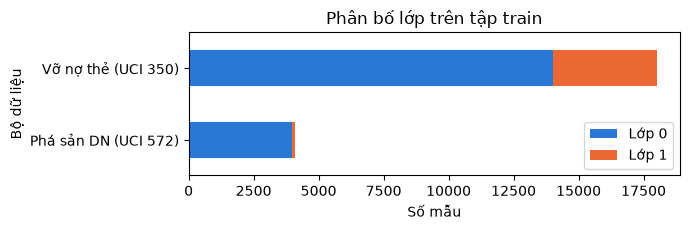

In [4]:
for name in DATASETS:
    info = inventory[name]
    print(f"{NAMES[name]}: {info['raw_rows']} dòng × {info['features']} đặc trưng, {info['positive']} mẫu lớp 1, "
          f"SHA-256 file gốc {info['sha256'][:12]}…")
    display(pd.DataFrame(info['raw_sample']))
counts = pd.DataFrame(rows).query("Tập == 'train'").set_index('Bộ dữ liệu')[['Lớp 0', 'Lớp 1']]
counts.plot.barh(stacked=True, figsize=(7, 2.4), color=['#2a78d6', '#eb6834'], title='Phân bố lớp trên tập train')
plt.xlabel('Số mẫu'); plt.tight_layout(); plt.show()

## 2. Một mô hình, ba cách cài đặt

Mã nguồn đầy đủ nằm trong `src/tieuluan/experiment_models.py` (hàm `scratch_model`, `torch_model`, `keras_model`)
và thư viện tự viết `src/tieuluan/scratch/`. Ô dưới in phần định nghĩa mô hình của ba hàm, rồi khởi tạo cả ba
bản bằng **cùng một bộ trọng số NumPy** và so sánh logit đầu ra trên vài mẫu (chưa huấn luyện).

In [5]:
import src.tieuluan.experiment_models as em
for fn in (em.scratch_model, em.torch_model, em.keras_model):
    print(inspect.getsource(fn))

def scratch_model(kind, input_shape, seed):
    rng = np.random.default_rng(seed)
    if kind == "mlp":
        return Sequential(Dense(input_shape[0], 16, rng=rng), ReLU(), Dense(16, 1, rng=rng))
    if kind in ("cnn4", "cnn8"):
        filters = 8 if kind == "cnn8" else 4
        return Sequential(Conv2d(1, filters, 3, rng=rng), ReLU(), MaxPool2d(2),       # 20 → 18 → 9
                          Flatten(), Dense(filters * 9 * 9, 1, rng=rng))
    if kind == "cnndeep":
        return Sequential(Conv2d(1, 4, 3, rng=rng), ReLU(), MaxPool2d(2),             # 20 → 18 → 9
                          Conv2d(4, 8, 3, rng=rng), ReLU(), MaxPool2d(2),             # 9 → 7 → 3
                          Flatten(), Dense(8 * 3 * 3, 1, rng=rng))
    cell = {"rnn": SimpleRNN, "lstm": LSTM, "gru": GRU}[kind]
    return Sequential(cell(input_shape[-1], HIDDEN, rng=rng), LastStep(), Dense(HIDDEN, 1, rng=rng))

def torch_model(kind, input_shape):
    import torch
    from torch import nn

    torch.set_num_

In [6]:
sample = data[DEMO]['train_' + REPRESENTATION][:8].astype(np.float32)
models = build_models(KIND, sample.shape[1:], seed=11)
logits = {FW[f]: predict_logits(m, f, sample) for f, m in models.items()}
display(pd.DataFrame(logits).round(6))
base = logits['NumPy tự viết']
print({k: float(np.max(np.abs(v - base))) for k, v in logits.items()}, '← lệch tuyệt đối lớn nhất so với NumPy')

,NumPy tự viết,PyTorch,Keras
0,1.226450,1.226450,1.226450
1,1.944412,1.944412,1.944412
2,0.303473,0.303474,0.303474
3,0.015213,0.015213,0.015213
4,0.641637,0.641637,0.641637
5,0.612750,0.612750,0.612750
6,1.403669,1.403669,1.403669
7,-0.234625,-0.234625,-0.234625


{'NumPy tự viết': 0.0, 'PyTorch': 2.384185791015625e-07, 'Keras': 2.384185791015625e-07} ← lệch tuyệt đối lớn nhất so với NumPy


## 3. Huấn luyện lại bằng ba cách (taiwan_bankruptcy, hạt giống 11)

Cả ba bản dùng cùng trọng số khởi tạo, cùng thứ tự mini-batch (batch 64), Adam với tốc độ học 0,001, cắt chuẩn
gradient ở 1,0, tối đa 60 epoch và dừng sớm sau 8 epoch không cải thiện BCE trên validation. Bảng so sánh ROC-AUC
vừa huấn luyện với giá trị đã lưu: bản NumPy và PyTorch thường trùng tới nhiều chữ số; Keras có thể lệch rất nhỏ do
cách đặt hằng số ε của Adam và thứ tự phép tính.

,Cài đặt,Epoch tốt nhất,Số epoch đã chạy,Giây,ROC-AUC vừa huấn luyện,ROC-AUC đã lưu,Lệch xác suất tối đa so với file đã lưu
0,NumPy tự viết,37,45,0.5,0.92156,0.92156,0.0
1,PyTorch,37,45,3.1,0.92156,0.92156,0.0
2,Keras,37,45,6.3,0.92185,0.92185,0.0


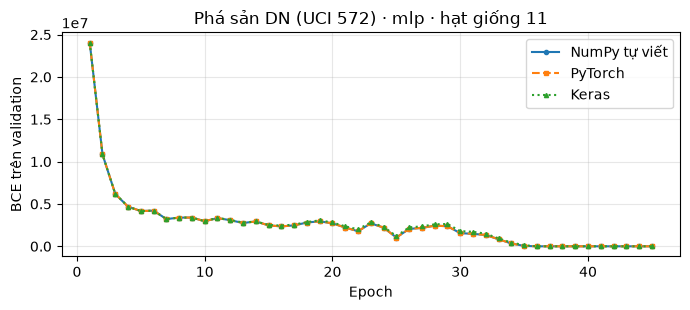

In [7]:
x, y = data[DEMO]['train_' + REPRESENTATION], data[DEMO]['train_y']
xv, yv = data[DEMO]['val_' + REPRESENTATION], data[DEMO]['val_y']
xt, yt = data[DEMO]['test_' + REPRESENTATION], data[DEMO]['test_y']
saved = {r['framework']: r for r in records if r['dataset'] == DEMO and r['kind'] == KIND and r['seed'] == 11}
rows, curves = [], {}
for framework in ('scratch', 'pytorch', 'keras'):
    model = build_models(KIND, x.shape[1:], seed=11, frameworks=(framework,))[framework]
    fit = fit_model(model, framework, KIND, x, y, xv, yv, seed=11, epochs=60, batch_size=64, patience=8)
    p = sigmoid(predict_logits(model, framework, xt))
    with np.load(RESULTS / f'{DEMO}__{KIND}__{framework}__11_predictions.npz') as archive:
        p_saved = archive['probability']
    curves[framework] = [h['val_loss'] for h in fit['history']]
    rows.append({'Cài đặt': FW[framework], 'Epoch tốt nhất': fit['best_epoch'], 'Số epoch đã chạy': fit['epochs_run'],
                 'Giây': round(fit['training_seconds'], 1), 'ROC-AUC vừa huấn luyện': round(roc_auc_score(yt, p), 5),
                 'ROC-AUC đã lưu': round(saved[framework]['metrics']['roc_auc'], 5),
                 'Lệch xác suất tối đa so với file đã lưu': float(np.max(np.abs(p - p_saved)))})
display(pd.DataFrame(rows))
fig, ax = plt.subplots(figsize=(7, 3.2))
for (framework, values), style in zip(curves.items(), ('-o', '--s', ':^')):
    ax.plot(range(1, len(values) + 1), values, style, ms=3, label=FW[framework])
ax.set_xlabel('Epoch'); ax.set_ylabel('BCE trên validation'); ax.set_title(f'{NAMES[DEMO]} · {KIND} · hạt giống 11')
ax.grid(alpha=.3); ax.legend(); plt.tight_layout(); plt.show()

## 4. Kết quả đầy đủ (3 hạt giống) và khoảng tin cậy

Bảng dưới tổng hợp các bản ghi đã lưu của chương (trung bình và độ lệch chuẩn qua 3 hạt giống), tiếp theo là
khoảng tin cậy 95% của ROC-AUC cho dự báo trung bình 3 hạt giống.

In [8]:
rows = []
for r in records:
    if r['dataset'] in DATASETS and r['kind'] in KINDS:
        rows.append({'Bộ dữ liệu': NAMES[r['dataset']], 'Mô hình': r['kind'], 'Cài đặt': FW[r['framework']],
                     'roc_auc': r['metrics']['roc_auc'], 'balanced_accuracy': r['metrics']['balanced_accuracy']})
table = (pd.DataFrame(rows).groupby(['Bộ dữ liệu', 'Mô hình', 'Cài đặt'])
         .agg(ROC_AUC_TB=('roc_auc', 'mean'), ROC_AUC_ĐLC=('roc_auc', 'std'),
              Balanced_acc=('balanced_accuracy', 'mean'), Số_lượt=('roc_auc', 'size')).round(4))
display(table)

ROC_AUC_TB  ROC_AUC_ĐLC  \
Bộ dữ liệu           Mô hình       Cài đặt                                  
Phá sản DN (UCI 572) logistic      scikit-learn       0.9182       0.0000   
                     majority      Đường cơ sở        0.5000          NaN   
                     mlp           Keras              0.9266       0.0042   
                                   NumPy tự viết      0.9264       0.0043   
                                   PyTorch            0.9264       0.0043   
                     random_forest scikit-learn       0.9752       0.0009   
Vỡ nợ thẻ (UCI 350)  logistic      scikit-learn       0.7376       0.0000   
                     majority      Đường cơ sở        0.5000          NaN   
                     mlp           Keras              0.7777       0.0011   
                                   NumPy tự viết      0.7782       0.0006   
                                   PyTorch            0.7782       0.0006   
                     random_forest scikit-learn       0.7813       0.0002   

                                                  Balanced_acc  Số_lượt  
Bộ dữ liệu           Mô hình       Cài đặt                               
Phá sản DN (UCI 572) logistic      scikit-learn         0.8686        3  
                     majority      Đường cơ sở          0.5000        1  
                     mlp           Keras                0.8774        3  
                                   NumPy tự viết        0.8779        3  
                                   PyTorch              0.8779        3  
                     random_forest scikit-learn         0.9210        3  
Vỡ nợ thẻ (UCI 350)  logistic      scikit-learn         0.6995        3  
                     majority      Đường cơ sở          0.5000        1  
                     mlp           Keras                0.7114        3  
                                   NumPy tự viết        0.7124        3  
                                   PyTorch              0.7133        3  
                     random_forest scikit-learn         0.7179        3

In [9]:
rows = [{'Bộ dữ liệu': NAMES[name], 'So sánh': key, 'Giá trị': round(item.get('auc', item.get('difference')), 4),
         'CI 95% thấp': round(item['low'], 4), 'CI 95% cao': round(item['high'], 4)}
        for name in DATASETS for key, item in analysis['uci'][name].items()]
display(pd.DataFrame(rows))

,Bộ dữ liệu,So sánh,Giá trị,CI 95% thấp,CI 95% cao
0,Phá sản DN (UCI 572),logistic,0.9182,0.8510,0.9691
1,Phá sản DN (UCI 572),random_forest,0.9757,0.9572,0.9886
2,Phá sản DN (UCI 572),mlp,0.9315,0.8672,0.9767
3,Phá sản DN (UCI 572),rf_minus_mlp,0.0442,-0.0009,0.1099
4,Phá sản DN (UCI 572),mlp_minus_logistic,0.0133,-0.0572,0.0790
5,Vỡ nợ thẻ (UCI 350),logistic,0.7376,0.7201,0.7539
6,Vỡ nợ thẻ (UCI 350),random_forest,0.7816,0.7662,0.7955
7,Vỡ nợ thẻ (UCI 350),mlp,0.7816,0.7665,0.7956
8,Vỡ nợ thẻ (UCI 350),rf_minus_mlp,-0.0000,-0.0063,0.0062
9,Vỡ nợ thẻ (UCI 350),mlp_minus_logistic,0.0440,0.0317,0.0566
